<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Classification_Model_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Let's build a simple classification model to predict whether the S&P 500 price will increase or decrease the next trading day.
#Step 1: Import the Required Libraries
# Machine learning classification
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import accuracy_score

# For data manipulation
import pandas as pd
import numpy as np
import yfinance as yf

# To plot
import matplotlib.pyplot as plt
import seaborn

/tmp/ipython-input-1740727322.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('SPY', start="2020-04-01", end="2025-11-20")
[*********************100%***********************]  1 of 1 completed


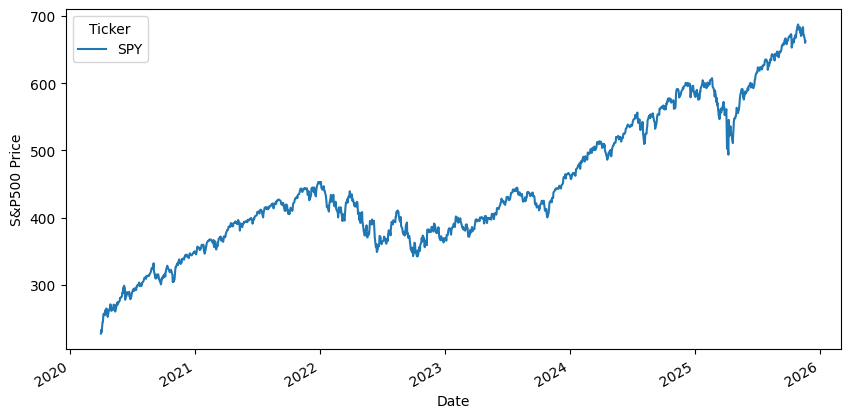

In [3]:
#Step 2: Get Your Data
# Download S&P 500 ETF (SPY) data
df = yf.download('SPY', start="2020-04-01", end="2025-11-20")
df = df.dropna() # Remove any missing values

# Plot the price history
df.Close.plot(figsize=(10,5))
plt.ylabel("S&P500 Price")
plt.show()

In [5]:
#Step 3: Define What You Want to Predict
# Create our target variable:
# If tomorrow's close is higher than today's, assign 1 (buy signal)
# If lower, assign -1 (sell signal)

y = np.where(df['Close'].shift(-1) > df['Close'], 1, -1)
# 1 means "buy" (price will go up)
# -1 means "sell" (price will go down)

In [6]:
#Step 4: Choose Your Prediction Features
# Create two simple features
df['Open-Close'] = df.Open - df.Close # Daily price change
df['High-Low'] = df.High - df.Low # Daily price range

# Select these columns as our prediction features
X = df[['Open-Close', 'High-Low']]

In [7]:
#Step 5: Split Data into Training and Testing Sets
split_percentage = 0.8
split = int(split_percentage * len(df))

# Train data set (80% of data)
X_train = X[:split]
y_train = y[:split]

# Test data set (remaining 20%)
X_test = X[split:]
y_test = y[split:]

In [8]:
#Step 6: Train Your Model
# Create and train the model
cls = SVC().fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [9]:
#Step 7: Check How Well Your Model Performs
# Check accuracy on training and testing data
accuracy_train = accuracy_score(y_train, cls.predict(X_train))
accuracy_test = accuracy_score(y_test, cls.predict(X_test))
print('\nTrain Accuracy:{: .2f}%'.format(accuracy_train * 100))
print('Test Accuracy:{: .2f}%'.format(accuracy_test * 100))


Train Accuracy: 55.47%
Test Accuracy: 56.69%


In [10]:
#Step 8: Make Predictions
# Make predictioPredicted_Signalns for the entire dataset
df['Predicted_Signal'] = 0.0
df.loc[X_test.index,'Predicted_Signal'] = cls.predict(X_test)

# Calculate log returns (percentage change)
df['Return'] = np.log(df.Close.shift(-1) / df.Close) * 100

# Calculate returns based on our strategy
df['Strategy_Return'] = df.Return * df.Predicted_Signal

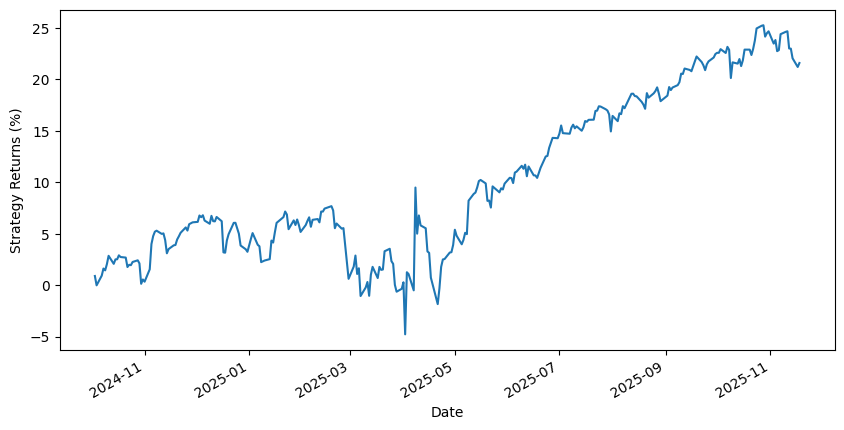

In [11]:
#Step 9: Visualise Your Results
# Plot cumulative returns for the test period
df.Strategy_Return.iloc[split:].cumsum().plot(figsize=(10,5))
plt.ylabel("Strategy Returns (%)")
plt.show()